In [2]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset

from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)


In [3]:
file_path = "/content/drive/MyDrive/Dataset/mental_health_binary_labeled.csv"
df = pd.read_csv(file_path)

df.head()

,text,sentiment,label
0,oh my gosh,Anxiety,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,0.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,0.0
3,I've shifted my focus to something else but I'...,Anxiety,0.0
4,"I'm restless and restless, it's been a month n...",Anxiety,0.0


In [4]:
df = df[['text', 'label']]
df.dropna(inplace=True)
df['label'] = df['label'].astype(int)

df['label'].value_counts()

,count
label,
0,36337
1,16343


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [6]:
train_df = pd.DataFrame({"text": X_train, "label": y_train})
test_df  = pd.DataFrame({"text": X_test,  "label": y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset  = Dataset.from_pandas(test_df)

In [7]:
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-large")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

Map:   0%|          | 0/42144 [00:00<?, ? examples/s]

Map:   0%|          | 0/10536 [00:00<?, ? examples/s]

In [8]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([0.7249, 1.6117])

In [9]:
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-large",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
class WeightedTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs   # ✅ absorbs num_items_in_batch safely
    ):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(model.device)
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [11]:
training_args = TrainingArguments(
    output_dir="./roberta_large_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    logging_steps=50,
    report_to="none"
)

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [13]:
data_collator = DataCollatorWithPadding(tokenizer)

In [14]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-2383804175.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.017600,0.207918,0.974848
2,0.048600,0.111985,0.978265
3,0.074400,0.211024,0.974184
4,0.069200,0.189004,0.979214
5,0.000000,0.221023,0.978740


TrainOutput(global_step=26340, training_loss=0.07172883364736406, metrics={'train_runtime': 10157.784, 'train_samples_per_second': 20.745, 'train_steps_per_second': 2.593, 'total_flos': 9.10690463343622e+16, 'train_loss': 0.07172883364736406, 'epoch': 5.0})

In [16]:
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Accuracy: 0.9792141230068337
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      7267
           1       0.97      0.96      0.97      3269

    accuracy                           0.98     10536
   macro avg       0.98      0.97      0.98     10536
weighted avg       0.98      0.98      0.98     10536



In [17]:
train_preds = trainer.predict(train_dataset)
y_train_pred = np.argmax(train_preds.predictions, axis=1)

from sklearn.metrics import accuracy_score
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

Training Accuracy: 0.9993356112376613


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    RocCurveDisplay
)


In [23]:
predictions = trainer.predict(test_dataset)


In [25]:
from scipy.special import softmax

In [26]:
logits = predictions.predictions
y_true = predictions.label_ids

y_prob = softmax(logits, axis=1)[:, 1]   # Positive class
y_pred = np.argmax(logits, axis=1)


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)


[[7168   99]
 [ 120 3149]]


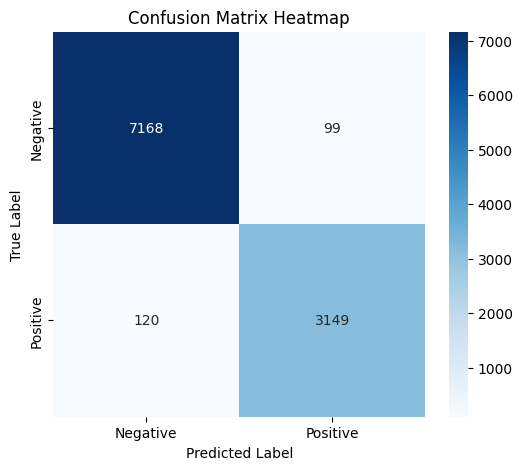

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


In [29]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)


AUC Score: 0.9971568654977769


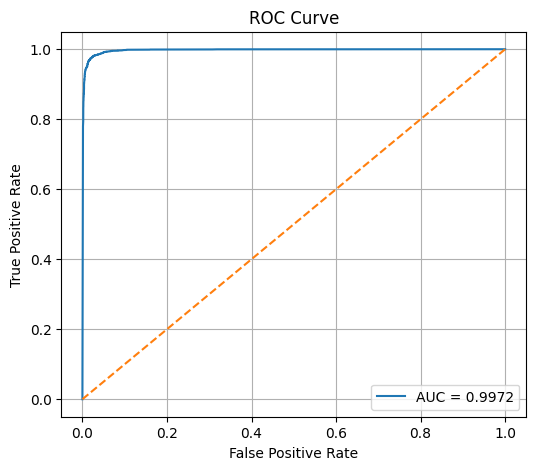

In [30]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
